#EDA

---



In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = '/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/.Process/Merge data/yt_comment.csv'

df = pd.read_csv(file_path)

In [4]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103606 entries, 0 to 103605
Data columns (total 1 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   comment_yt  102189 non-null  object
dtypes: object(1)
memory usage: 809.6+ KB


(103606, 1)

In [5]:
df.head()

,comment_yt
0,Kalo rakyat kompak siapapun anggota dari insti...
1,❤❤❤❤❤ mantap
2,Ahmad Syahroni = amit amit jabang bayi.
3,Alhamdulillah tamunya Satroni buanyak bersilst...
4,Waduuhhhh. Indonesia kok seperti Nepal Ya?? T...


##Analisis Missing Values

In [6]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Jumlah Missing': missing.values,
    'Persentase (%)': (missing.values / len(df)) * 100
})

print(missing_df)

   Jumlah Missing  Persentase (%)
0            1417        1.367681


##Analisis Duplicate Data

In [7]:
duplicate_count = df['comment_yt'].duplicated().sum()

print(f"Jumlah data duplikat: {duplicate_count}")


duplicates = df[df.duplicated()]
print(duplicates[['comment_yt']])

Jumlah data duplikat: 7553
                                               comment_yt
66      Brg2 tersebut dibeli dari uang rakyat, jadi wa...
172                                                  😂😂😂😂
308     Ruumah. Hasill dwek rajyat iki wes dii bbakkaa...
315                                                Mantap
350                                                Mantap
...                                                   ...
103565                                     Ini baru keren
103570             Dari rakyat, oleh rakyat, untuk rakyat
103573                                             Setuju
103575                                               Puan
103597  para koruptor perlu diperlakukan gni oleh raky...

[7553 rows x 1 columns]


##Analisis Noise

In [8]:
# Pastikan data string
df.columns = df.columns.str.strip()

print(df.columns)

Index(['comment_yt'], dtype='object')


Deteksi URL

In [9]:
import re

url_pattern = r'http\S+|www\S+'

df['contains_url'] = df['comment_yt'].apply(
    lambda x: bool(re.search(url_pattern, str(x)))
)

print(df['contains_url'].value_counts())

print(df[df['contains_url']]['comment_yt'].head())

contains_url
False    103591
True         15
Name: count, dtype: int64
17515    UPDATE PAGI Masih Dijarah Rumah Anggota DPR Uy...
17807    Jika ada yang di tangkap kelak karna penjaraha...
18325    Bukan ngejarah brooowww...😅😅😅mereka mengambil....
18677    video guru beban negra adlah video editan AI D...
19706    😮😮😮Wowwww satu persatu di kupas kulit nyaaaaa....
Name: comment_yt, dtype: object


Deteksi Hashtag

In [10]:
hashtag_pattern = r'#\w+'

df['contains_hashtag'] = df['comment_yt'].apply(
    lambda x: bool(re.search(hashtag_pattern, str(x)))
)

print(df['contains_hashtag'].value_counts())

print(df[df['contains_hashtag']]['comment_yt'])

contains_hashtag
False    103596
True         10
Name: count, dtype: int64
19768    Itulah bahayanya Membiarkan buzzer & ternak mu...
19923    Lebay loe Min  !!! \nkemana aja loe selama Sri...
22960    Anjirrr parah ini...😂😂 menteri2 yg sombong dan...
24195    Koruptor... \n\nHukum minimal 35 tahun\n\nMax ...
25861    Sangat bahagaia meskipun gk ikut kezana #realp...
26374           #Sri_Mulyani #iblis yang berbentuk manusia
26822    *#ORMAS,,... GK PENGARUH KLO PERUT RAKYAT SUDA...
37347    Jangan sampe terkecoh dari titik fokus, kemati...
66403    KOMEN #2\n\nPada kemana sih yah? 🤔\nkalau bena...
91787    Perampasan aset jilid#1... akhirnya rakyat yg ...
Name: comment_yt, dtype: object


Deteksi Mention

In [11]:
mention_pattern = r'@\w+'

df['contains_mention'] = df['comment_yt'].apply(
    lambda x: bool(re.search(mention_pattern, str(x)))
    if pd.notnull(x) else False
)

print(df['contains_mention'].value_counts())

df[df['contains_mention']]

contains_mention
False    103238
True        368
Name: count, dtype: int64


,comment_yt,contains_url,contains_hashtag,contains_mention
26,JAKARTA – Ahli Dewan Perwakilan Rakyat (DPR) R...,False,False,True
878,Mantapp @BUBARKANDPR,False,False,True
1181,Share lock baaang! 👍​@NexterraBarat,False,False,True
1414,​@fadilahalifatuzkoriah5975gausah om...ini war...,False,False,True
1416,"​@fadilahalifatuzkoriah5975lah sama Bang, mau ...",False,False,True
...,...,...,...,...
103477,​@inisial.123bukan kelamaan tapi nggak di setu...,False,False,True
103489,​@budiastuti5185Alhamdulillah kembalikan kepad...,False,False,True
103512,​@pencarikebenaran1116BETUL...DIA BELI.BRG2 IT...,False,False,True
103577,​@Meongorenchannel19Next 😂,False,False,True


Deteksi Emoji

In [12]:
emoji_pattern = re.compile(
    "["
    u"\U0001F600-\U0001F64F"  # emoticon
    u"\U0001F300-\U0001F5FF"  # simbol & pictograph
    u"\U0001F680-\U0001F6FF"  # transport
    u"\U0001F1E0-\U0001F1FF"  # flags
    "]+",
    flags=re.UNICODE
)

df['contains_emoji'] = df['comment_yt'].apply(
    lambda x: bool(emoji_pattern.search(str(x)))
)

print(df['contains_emoji'].value_counts())

print(df[df['contains_emoji']]['comment_yt'])

contains_emoji
False    84071
True     19535
Name: count, dtype: int64
12                   coba sekali lagi berani ngatain tolol😂
20        Maling pasar.\nMaling rumahan .\nMaling kebon....
23        Siap² anggota DPR yg bnyak cete,,,ni gini kond...
35        Gw sbenernya gak setuju ada penjarahan.. Tapi ...
37                                    Rumah di looting cik😂
                                ...                        
103577                           ​@Meongorenchannel19Next 😂
103583                Mantap ini adalah uu perampasan aset😂
103584                                            Masokkkk😂
103598                                   Perampasan aset🔥😀💪
103605    aset yang di sahkan pendemo ngga  dpr kelamaan...
Name: comment_yt, Length: 19535, dtype: object


Deteksi Simbol Berlebih

In [13]:
symbol_pattern = r'[^\w\s]'

df['contains_symbol'] = df['comment_yt'].apply(
    lambda x: bool(re.search(symbol_pattern, str(x)))
)

print(df['contains_symbol'].value_counts())

print(df[df['contains_symbol']]['comment_yt'].head())

contains_symbol
True     66628
False    36978
Name: count, dtype: int64
0    Kalo rakyat kompak siapapun anggota dari insti...
1                                         ❤❤❤❤❤ mantap
2              Ahmad Syahroni = amit amit jabang bayi.
3    Alhamdulillah tamunya Satroni buanyak bersilst...
4    Waduuhhhh. Indonesia kok seperti Nepal Ya??  T...
Name: comment_yt, dtype: object


Deteksi Karakter Berulang
*   baguusssss
*   mantapppp



In [14]:
repeat_pattern = r'(.)\1{4,}'

df['contains_repeated_char'] = df['comment_yt'].apply(
    lambda x: bool(re.search(repeat_pattern, str(x).lower()))
)

print(df['contains_repeated_char'].value_counts())

print(df[df['contains_repeated_char']]['comment_yt'].head())


contains_repeated_char
False    97697
True      5909
Name: count, dtype: int64
1                                          ❤❤❤❤❤ mantap
40    Yg penting black mamba milik istrinya msih ama...
60                             Hancur dan malu 😝😝😝😝😝😝😝😝
67                   👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍Rakyat 💪💪💪💪🙏💪💪
81                                              😂😂😂😂😂😂😂
Name: comment_yt, dtype: object


Deteksi Teks Irrelevant
*   terlalu pendek
*   hanya angka/simbol



In [15]:
def irrelevant_text(text):

    text = str(text).strip()

    # terlalu pendek
    if len(text) < 3:
        return True

    # hanya angka/simbol
    if re.fullmatch(r'[\W\d_]+', text):
        return True

    return False

df['irrelevant_text'] = df['comment_yt'].apply(irrelevant_text)

print(df['irrelevant_text'].value_counts())

print(df[df['irrelevant_text']]['comment_yt'])

irrelevant_text
False    101334
True       2272
Name: count, dtype: int64
62                   ❤❤❤
81               😂😂😂😂😂😂😂
91                  😂😂😂😂
112                   😂😊
127       😮😮😅😅😅😅😮😅😅😅😅😅😅😅
               ...      
103234             😂😂😂😂😂
103277               🎉🎉🎉
103432        😂😂😂😂😂.....
103459          🤣🤣🤣🤣🤣🤣🤣🤣
103463              😂😂😂😂
Name: comment_yt, Length: 2272, dtype: object


Ringkasan Noise


===== RINGKASAN NOISE =====
          Jenis Noise  Jumlah
0          URL/Tautan      15
1             Hashtag      10
2             Mention     368
3   Karakter Berulang    5909
4  Teks Tidak Relevan    2272


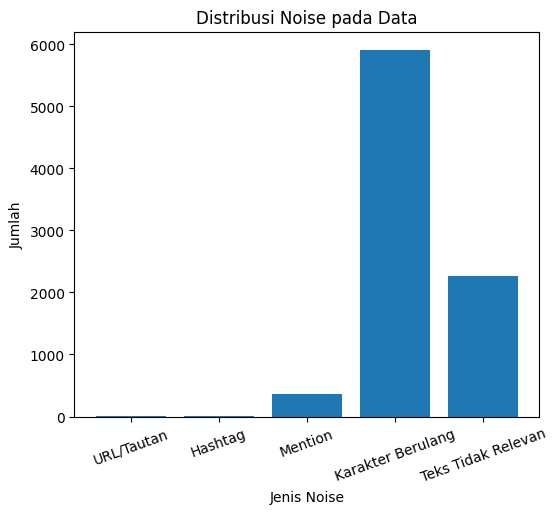

In [16]:
noise_summary = {
    'URL/Tautan': df['contains_url'].sum(),
    'Hashtag': df['contains_hashtag'].sum(),
    'Mention': df['contains_mention'].sum(),
    #'Emoji': df['contains_emoji'].sum(),
    #'Simbol': df['contains_symbol'].sum(),
    'Karakter Berulang': df['contains_repeated_char'].sum(),
    'Teks Tidak Relevan': df['irrelevant_text'].sum()
}

noise_df = pd.DataFrame(
    noise_summary.items(),
    columns=['Jenis Noise', 'Jumlah']
)

print("\n===== RINGKASAN NOISE =====")
print(noise_df)

# Visualisasi Noise
plt.figure(figsize=(6,5))
plt.bar(noise_df['Jenis Noise'], noise_df['Jumlah'])
plt.title('Distribusi Noise pada Data')
plt.xlabel('Jenis Noise')
plt.ylabel('Jumlah')
plt.xticks(rotation=20)
plt.show()

#PREPROCESSING

---



In [17]:
#copy dataset, agar data asli tidak berubah
clean_df = df.copy()

##Case Folding

In [18]:
clean_df['clean_text'] = clean_df['comment_yt'].str.lower()
print(clean_df[['clean_text']].head())

                                          clean_text
0  kalo rakyat kompak siapapun anggota dari insti...
1                                       ❤❤❤❤❤ mantap
2            ahmad syahroni = amit amit jabang bayi.
3  alhamdulillah tamunya satroni buanyak bersilst...
4  waduuhhhh. indonesia kok seperti nepal ya??  t...


##Noise Removal

In [19]:
import re

def clean_noise(text):

    text = str(text)

    #hapus url
    text = re.sub(r'http\S+|www\S+', '', text)

    #hapus hashtag
    text = re.sub(r'#', '', text)

    #hapus mention
    text = re.sub(r'@+w', '', text)

    #hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

clean_df['clean_text'] = clean_df['clean_text'].apply(clean_noise)

##Normalisasi

Ubah Karakter Berulang

In [20]:
def normalize_repeated_char(word):

    word = re.sub(r'(.)\1{2,}', r'\1', word)

    return word


def normalize_text(text):

    words = text.split()

    normalized_words = [
        normalize_repeated_char(word)
        for word in words
    ]

    return ' '.join(normalized_words)

clean_df['clean_text'] = clean_df['clean_text'].apply(normalize_text)
print(clean_df[['clean_text']].head())

                                          clean_text
0  kalo rakyat kompak siapapun anggota dari insti...
1                                           ❤ mantap
2            ahmad syahroni = amit amit jabang bayi.
3  alhamdulillah tamunya satroni buanyak bersilst...
4  waduuh. indonesia kok seperti nepal ya?? tahan...


##Cleaning Data

Hapus Missing Value

In [21]:
clean_df = clean_df.dropna(subset=['clean_text'])

print("Jumlah data setelah hapus missing value:")
print(len(clean_df))

Jumlah data setelah hapus missing value:
103606


Hapus Duplikat Data

In [22]:
clean_df = clean_df.drop_duplicates(subset=['clean_text'])

print("\nJumlah data setelah hapus duplikat:")
print(len(clean_df))


Jumlah data setelah hapus duplikat:
94170


Hapus Teks tidak Relevan

In [23]:
def irrelevant_text(text):

    text = text.strip()

    # terlalu pendek
    if len(text) < 3:
        return True

    # hanya simbol/angka
    if re.fullmatch(r'[\W\d_]+', text):
        return True

    return False

clean_df = clean_df[
    ~clean_df['clean_text'].apply(irrelevant_text)
]

print(len(clean_df))

93878


#HASIL

In [24]:
print("\n===== HASIL PREPROCESSING =====")

print(clean_df[['comment_yt', 'clean_text']].head(10))

print("\nJumlah data akhir:")
print(len(clean_df))


===== HASIL PREPROCESSING =====
                                          comment_yt  \
0  Kalo rakyat kompak siapapun anggota dari insti...   
1                                       ❤❤❤❤❤ mantap   
2            Ahmad Syahroni = amit amit jabang bayi.   
3  Alhamdulillah tamunya Satroni buanyak bersilst...   
4  Waduuhhhh. Indonesia kok seperti Nepal Ya??  T...   
5                               Memalukan jd manusia   
6                           Intinya ada asap ada api   
7  Ikut hukum dunia mmg xde hk As biar pun bata s...   
8  iki jenenge pengadilan rakyat sangat adil kang...   
9  Padahal ada lagi tuh mobil mewah lebih dari 10...   

                                          clean_text  
0  kalo rakyat kompak siapapun anggota dari insti...  
1                                           ❤ mantap  
2            ahmad syahroni = amit amit jabang bayi.  
3  alhamdulillah tamunya satroni buanyak bersilst...  
4  waduuh. indonesia kok seperti nepal ya?? tahan...  
5                   

#SIMPAN HASIL

In [25]:
import os

final_df = clean_df[['clean_text']].copy()

# ubah nama kolom
final_df.columns = ['yt_clean']

In [26]:
folder_path = '/content/drive/MyDrive/SKRIPSI MANTAP/.Process/data sosmed/Clean data'

os.makedirs(folder_path, exist_ok=True)

Simpan ke gdrive

In [27]:
output_path = f'{folder_path}/yt_clean.csv'

final_df.to_csv(output_path, index=False)

print("File berhasil disimpan di:")
print(output_path)

File berhasil disimpan di:
/content/drive/MyDrive/SKRIPSI MANTAP/.Process/data sosmed/Clean data/yt_clean.csv


Download

In [28]:
from google.colab import files

files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#DISTRIBUSI JUMLAH KATA TIAP KOMENTAR

---



In [29]:
# ======================================
# Distribusi Panjang Komentar
# ======================================

# Hitung jumlah kata pada setiap komentar
clean_df['word_count'] = clean_df['clean_text'].apply(
    lambda x: len(str(x).split())
)

# Hitung jumlah komentar pada setiap rentang
less_50 = (clean_df['word_count'] < 50).sum()
between_50_99 = ((clean_df['word_count'] >= 50) & (clean_df['word_count'] < 100)).sum()
between_100_199 = ((clean_df['word_count'] >= 100) & (clean_df['word_count'] < 200)).sum()
more_equal_200 = (clean_df['word_count'] >= 200).sum()

total = len(clean_df)

print("Distribusi Panjang Komentar")
print("="*40)
print(f"< 50 kata      : {less_50} komentar ({less_50/total*100:.2f}%)")
print(f"50-99 kata     : {between_50_99} komentar ({between_50_99/total*100:.2f}%)")
print(f"100-199 kata   : {between_100_199} komentar ({between_100_199/total*100:.2f}%)")
print(f"≥ 200 kata     : {more_equal_200} komentar ({more_equal_200/total*100:.2f}%)")

Distribusi Panjang Komentar
< 50 kata      : 92575 komentar (98.61%)
50-99 kata     : 1112 komentar (1.18%)
100-199 kata   : 173 komentar (0.18%)
≥ 200 kata     : 18 komentar (0.02%)
